# Cylindrical Shell Theta Baseline

This baseline uses centered cylindrical shell bands.

Each shell is defined by successive outer boundaries:
- `R_i = R_max * (i / n_shells)^(scale_power)`
- `Z_i = Z_max * (i / n_shells)^(scale_power)`

Where scale_power is a user defined value. Default is 1/3

The target is `inside_shell`, meaning an event lies inside shell band `i` and outside shell band `i-1`.


In [1]:
from __future__ import annotations

import json
import yaml
import os
import sys
from pathlib import Path
import numpy as np

import pandas as pd
from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "PROJECT_EXPERIMENT_GUIDE.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root from the current working directory.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
CNP_MFGP_ROOT = REPO_ROOT / "cnp_mfgp"
if str(CNP_MFGP_ROOT) not in sys.path:
    sys.path.insert(0, str(CNP_MFGP_ROOT))
    
from cnp_clean_pipeline import load_runtime_config, predict_cnp, train_cnp
from mfgp_clean_pipeline import run_mfgp_transform_suite

PREP_CONFIG_PATH = REPO_ROOT / "cnp_mfgp" / "config" / "pipeline_config.json"
NOTEBOOK_CONFIG_PATH = REPO_ROOT / "cnp_mfgp" / "config" / "runtime_notebook_config.json"
CONFIG_PATH = REPO_ROOT / "cnp_mfgp" / "config" / "settings_shell_minibatch.yaml"
VALIDATION_CONFIG_PATH = REPO_ROOT / "cnp_mfgp" / "config" / "settings_shell_validation_minibatch.yaml"

SEED = 42
STEPS_PER_EPOCH = 5000
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
REPR_DIM = 32
HIDDEN = 128
DROPOUT = 0.0
MONITOR_EVERY = 5000
MC_SAMPLES = 30
CHUNK_SIZE = 20000
GRID_POINTS = 60
RANDOM_STATE = 42
TARGET_TRANSFORMS = ["linear", "log_hf", "log_lf", "log_both"]


## 1. Choose Notebook Parameters

Edit these values here instead of changing the default JSON config.


In [2]:
NOTEBOOK_PARAMS = {
    "n_shells": 100,
    "min_candidate_events": 1,
    "max_events_per_file": None,
    "lf_block_size": 20000,
    "hf_block_size": 100000,
    "validation_block_size": None,
    "scale_power": 1.0/3.0
}

pd.DataFrame({
    "parameter": list(NOTEBOOK_PARAMS.keys()),
    "value": list(NOTEBOOK_PARAMS.values()),
})


,parameter,value
0,n_shells,100.000000
1,min_candidate_events,1.000000
2,max_events_per_file,NaN
3,lf_block_size,20000.000000
4,hf_block_size,100000.000000
5,validation_block_size,NaN
6,scale_power,0.333333


## Parameter Guide

- `n_shells`: Number of shells. Higher value means thinner and more spacial resolution. Lower means thicker and more events per shell
- `min_candidate_events`: Minimum number of events in a shell to consider it a "candidate" for training. Shells below this are ignored for training
- `max_events_per_file`: Maximum number of events to draw from each file read in. Higher means well-supported shells survive. Lower means more shells involved, but noisier.
- `lf_block_size`: Number of events per lf block. High means fewer LF blocks. Lower means more LF files per block
- `hf_block_size`: Same as lf_block_size but for hf data
- `validation_block_size` Same as lf_block_size but for validation data. If None is same as hf
- `scale_power`: Power of the scaling of shells. Cube root means equal volume - default is 1/3

This notebook writes a temporary runtime config but always reuses the same dataset folder:
- `outputs/cnp_mfgp`

So rerunning the prep command overwrites the previous equal-volume shell dataset instead of creating a new dataset tree each time.


## 2. Build A Runtime Config From Those Parameters


In [3]:
prep_config = json.loads(PREP_CONFIG_PATH.read_text())
prep_config["file_load"]["max_rows_per_file"] = NOTEBOOK_PARAMS["max_events_per_file"]
prep_config["shell"]["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
prep_config["shell"]["min_candidate_events"] = int(NOTEBOOK_PARAMS["min_candidate_events"])
prep_config["sampling"]["lf_block_size"] = int(NOTEBOOK_PARAMS["lf_block_size"])
prep_config["sampling"]["hf_block_size"] = int(NOTEBOOK_PARAMS["hf_block_size"])
prep_config["sampling"]["validation_block_size"] = NOTEBOOK_PARAMS["validation_block_size"]
prep_config["shell"]["scale_power"] = float(NOTEBOOK_PARAMS["scale_power"])

NOTEBOOK_CONFIG_PATH.write_text(json.dumps(prep_config, indent=2))

# Make sure the yamls have the correct shell geometry
for yaml_path in [CONFIG_PATH, VALIDATION_CONFIG_PATH]:
    yaml_config = yaml.safe_load(yaml_path.read_text())
    sim = yaml_config["simulation_settings"]
    sim["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
    sim["theta_headers"] = ["detector_R", "detector_Z"]
    sim["phi_labels"] = ["s_r", "s_z_from_center"]
    sim["target_headers"] = ["target_shell"]

    yaml_path.write_text(
        yaml.safe_dump(
            yaml_config,
            sort_keys=False,
        )
    )

runtime = load_runtime_config(CONFIG_PATH, seed=SEED)
validation_runtime = load_runtime_config(VALIDATION_CONFIG_PATH, seed=SEED)

summary = pd.DataFrame({
    "field": [
        "version",
        "n_shells",
        "min_candidate_events",
        "lf_block_size",
        "hf_block_size",
        "validation_block_size",
        "theta_headers",
        "phi_headers",
        "target_headers",
        "scale_power",
        "R/Z source",
    ],
    "value": [
        runtime.version,
        prep_config["shell"].get("n_shells"),
        prep_config["shell"].get("min_candidate_events"),
        prep_config["sampling"].get("lf_block_size"),
        prep_config["sampling"].get("hf_block_size"),
        prep_config["sampling"].get("validation_block_size"),
        ", ".join(runtime.theta_headers),
        ", ".join(runtime.phi_headers),
        ", ".join(runtime.target_headers),
        prep_config["shell"].get("scale_power"),
        "file_manifest.csv if provided; otherwise inferred per file",
    ],
})
summary


,field,value
0,version,xlzd_shell_minibatch
1,n_shells,100
2,min_candidate_events,1
3,lf_block_size,20000
4,hf_block_size,100000
5,validation_block_size,None
6,theta_headers,"detector_R, detector_Z"
7,phi_headers,"s_r, s_z_from_center"
8,target_headers,target_shell
9,scale_power,0.333333


## 3. Prepare The Shell Dataset

Run this from the repo root before training if the dataset has not been built yet.

If you want more inner-shell candidates, lower `min_candidate_events` first. If you want fewer repeated shell assignments, increase `lf_block_size`.

This prep step now clears and rebuilds `outputs/cnp_mfgp`, so changing notebook parameters refreshes the same dataset instead of leaving old files behind.


In [4]:
import subprocess

cmd = [
    sys.executable,
    "cnp_mfgp/prepare_cnp_mfgp_data.py",
    "--config",
    str(NOTEBOOK_CONFIG_PATH.relative_to(REPO_ROOT)),
]

print("$ " + " ".join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)

$ /home/liuser/miniconda3/bin/python cnp_mfgp/prepare_cnp_mfgp_data.py --config cnp_mfgp/config/runtime_notebook_config.json

[15:38:30] Clearing existing dataset directory: cnp_mfgp/outputs/datasets
[done in 0.39s] Removed previous shell dataset

[15:38:30] Loading file manifest
[done in 0.01s] Loaded 7 manifest rows from data/file_manifest.csv

Processing manifest row 1
source_file=CathodeGrid_2447keVgamma_ROI1sigma_SScut_vetoapplied.csv
manifest R=1490.0, Z=1983.0
fidelity=0

[15:38:30] Loading CathodeGrid_2447keVgamma_ROI1sigma_SScut_vetoapplied.csv
[done in 1.48s] Loaded 2,107,384 rows

[15:38:32] Using detector geometry and fidelity from manifest
[done in 0.11s] Using manifest values: fidelity=0, z_center=1982.5, R=1490, Z=1983

[15:38:32] Building shell table and assigning target shells
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[done in 0.72s] Assigned shells for 2,107,384/2,107,384 events

Processing man

CompletedProcess(args=['/home/liuser/miniconda3/bin/python', 'cnp_mfgp/prepare_cnp_mfgp_data.py', '--config', 'cnp_mfgp/config/runtime_notebook_config.json'], returncode=0)

## 4. Train The CNP


[warn] Shell classes with zero training examples: [0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 15]

[class weights]
min count: 1
max count: 513247
min weight: 0.0104
max weight: 7.4555

[info] Random mini-batch mode is enabled. Each epoch uses 5000 sampled steps.


Epoch 1/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

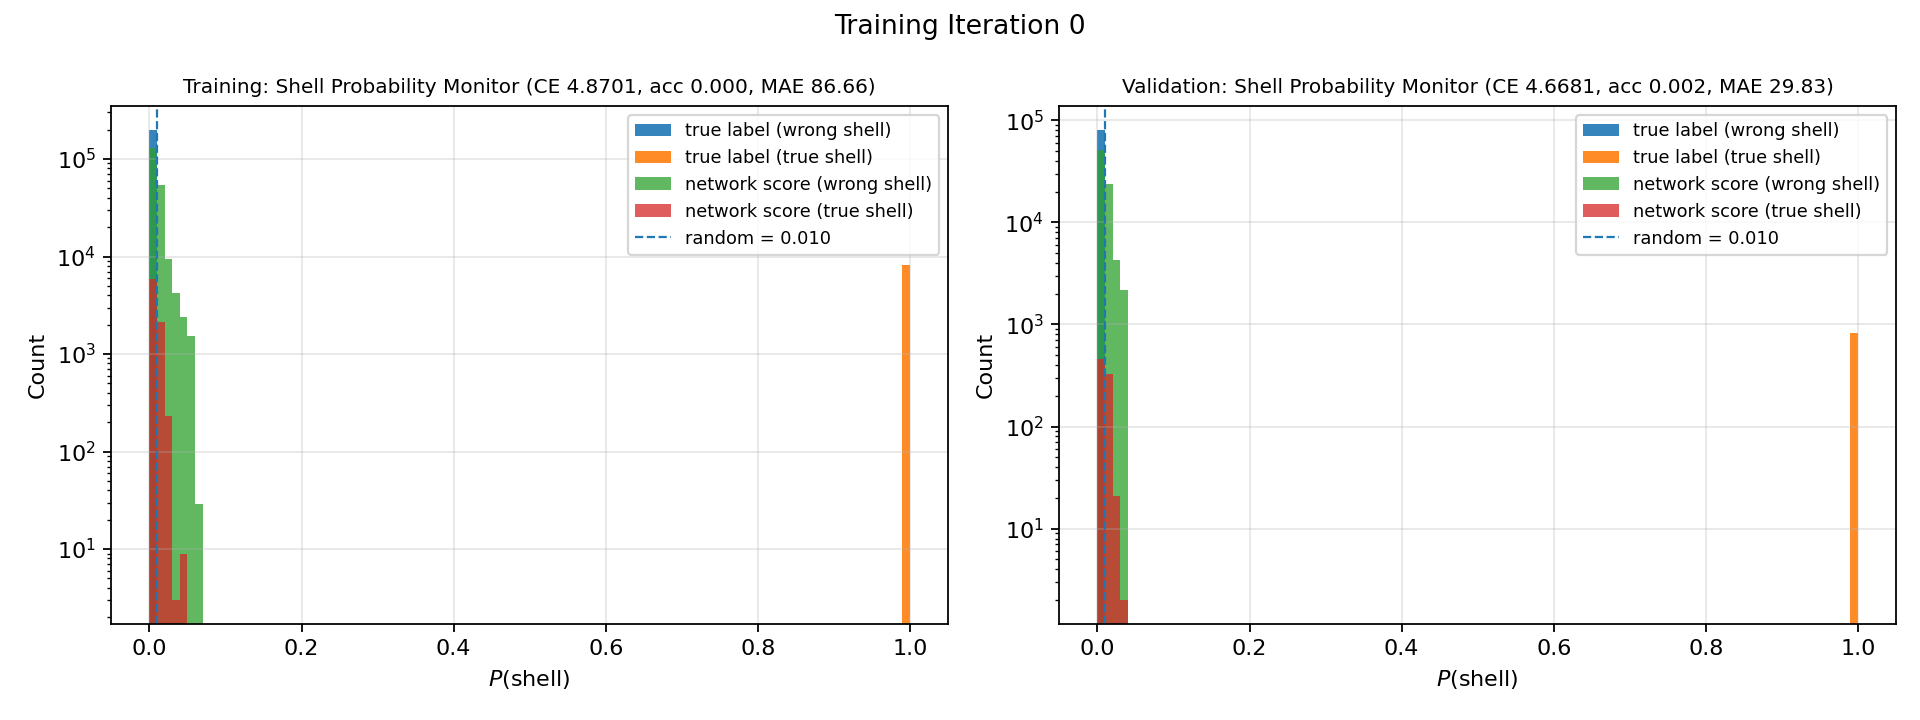

Epoch 2/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

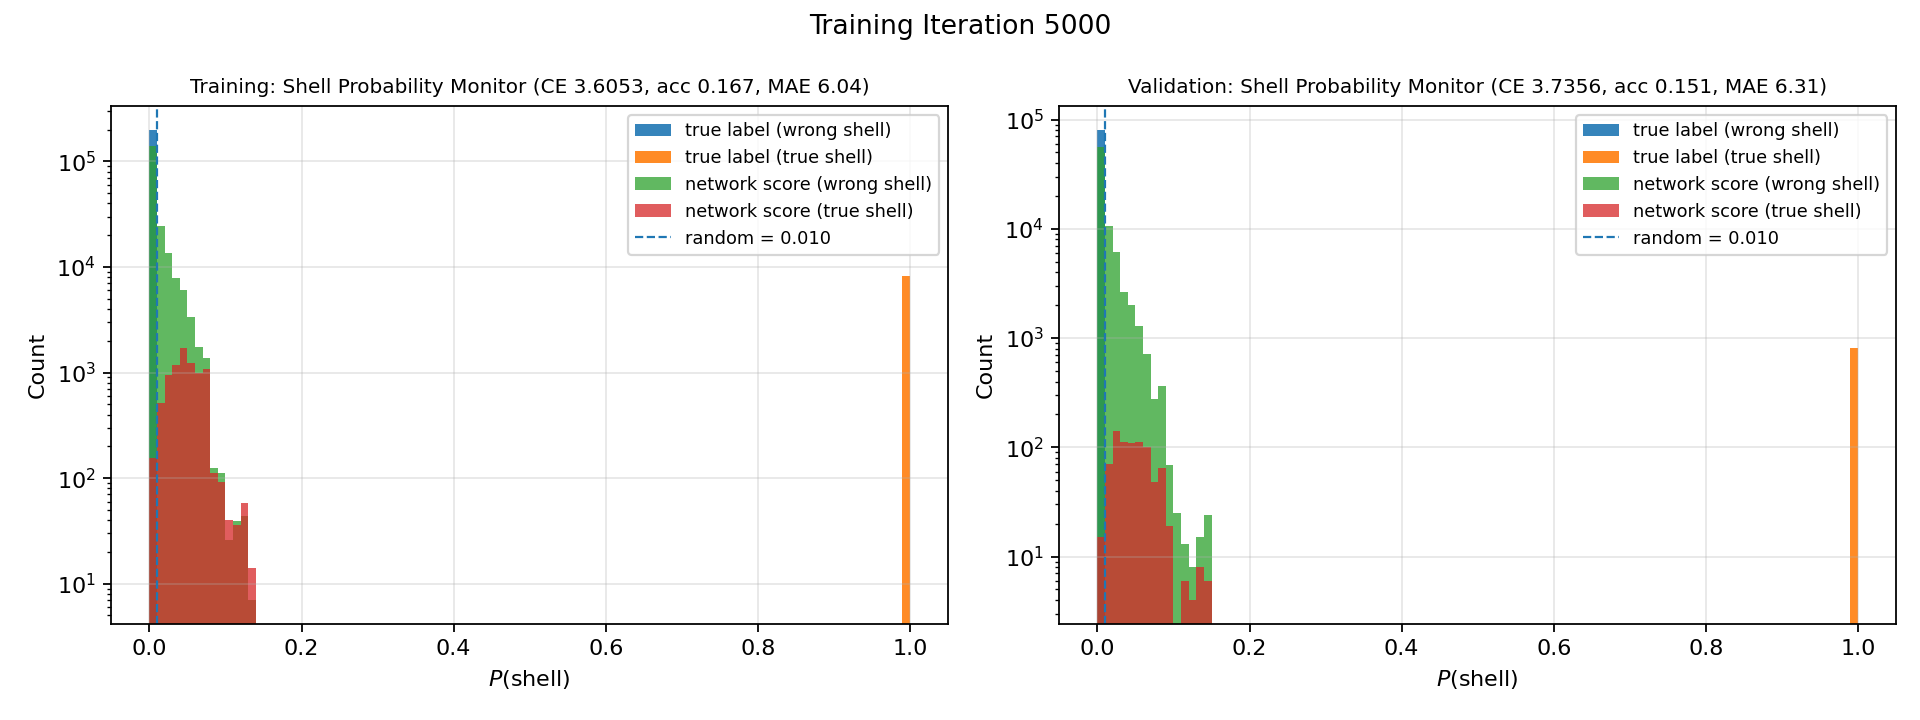

Epoch 3/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

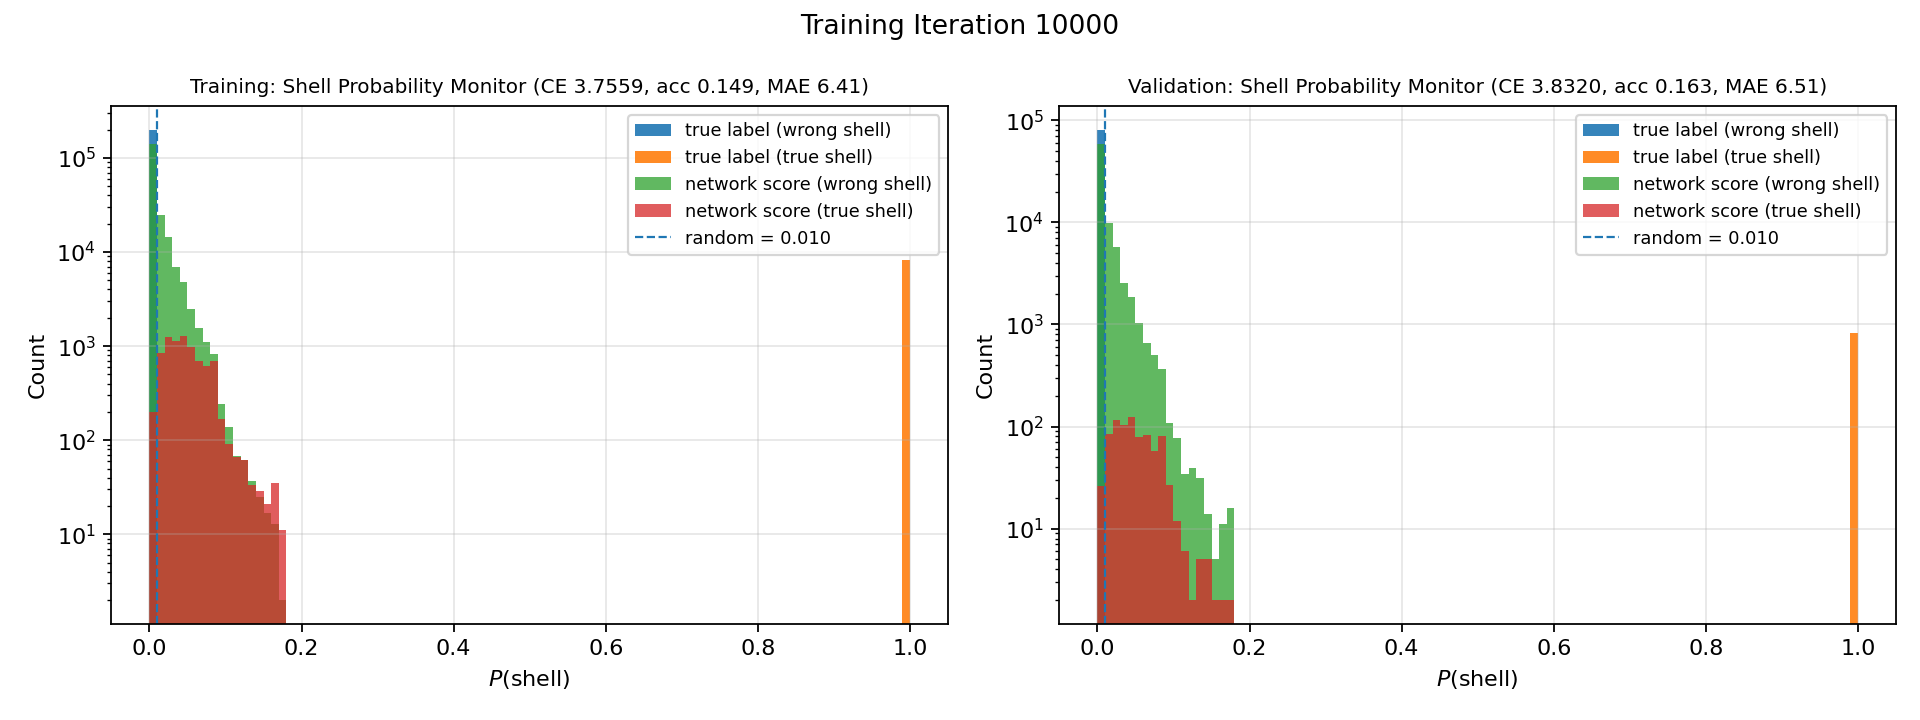

Epoch 4/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

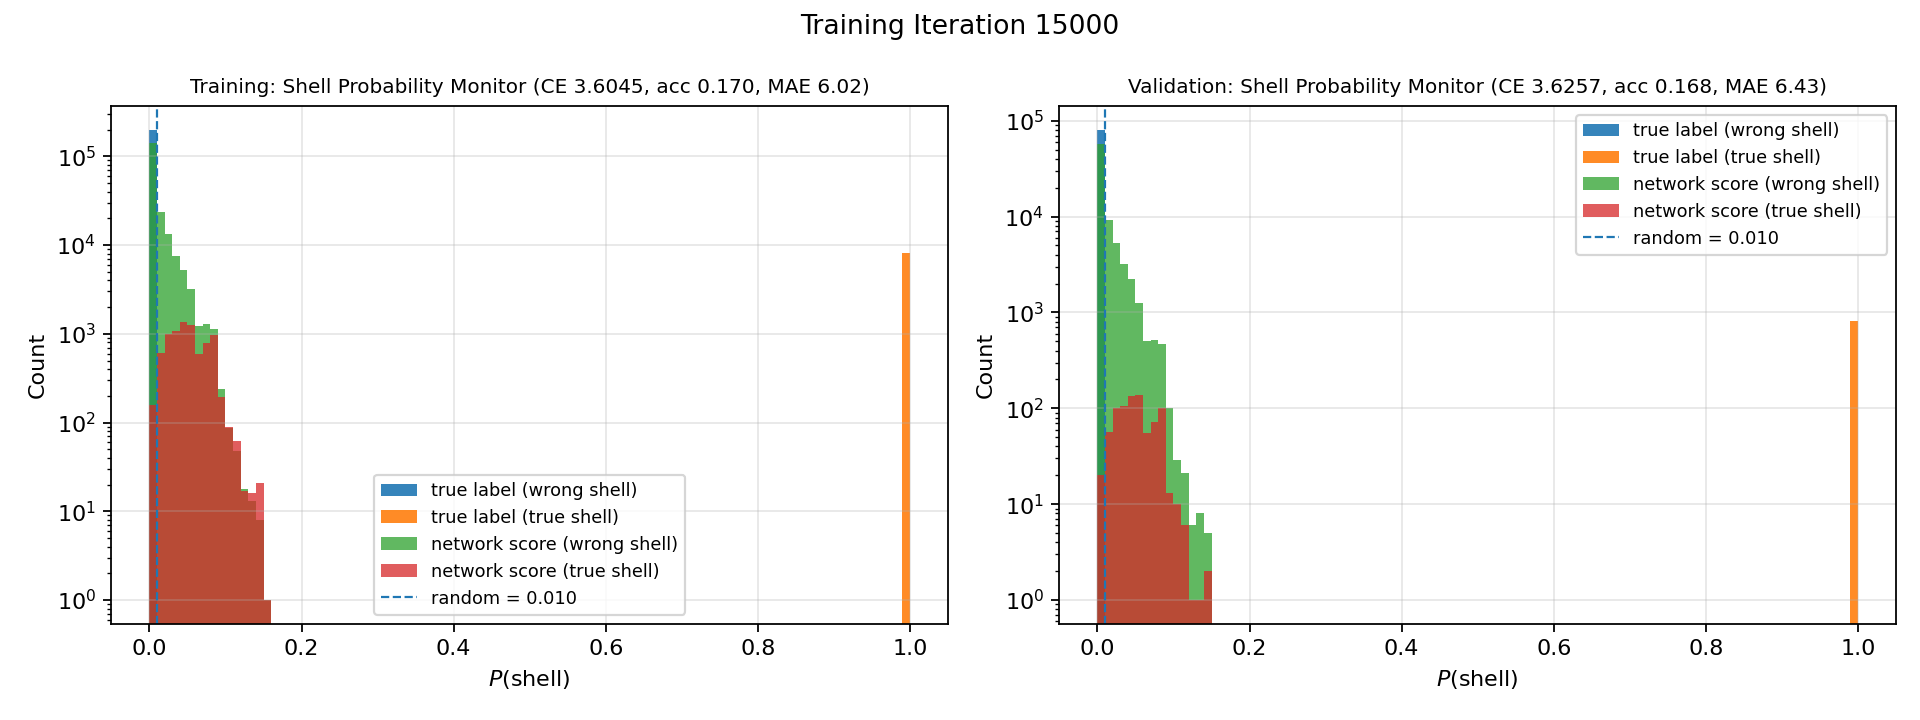

Epoch 5/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

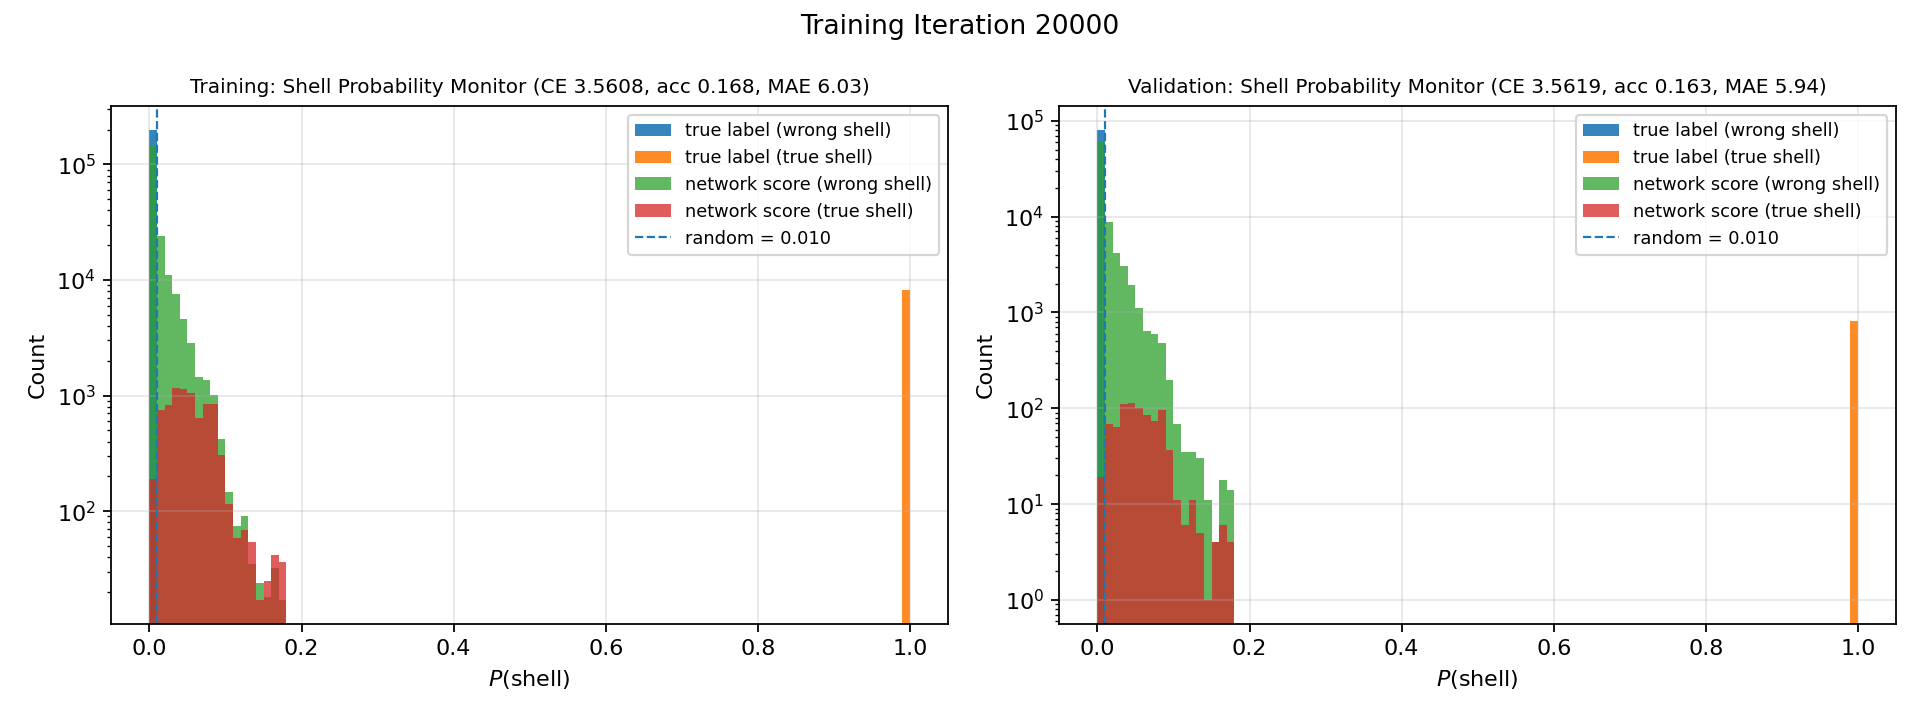

Epoch 6/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

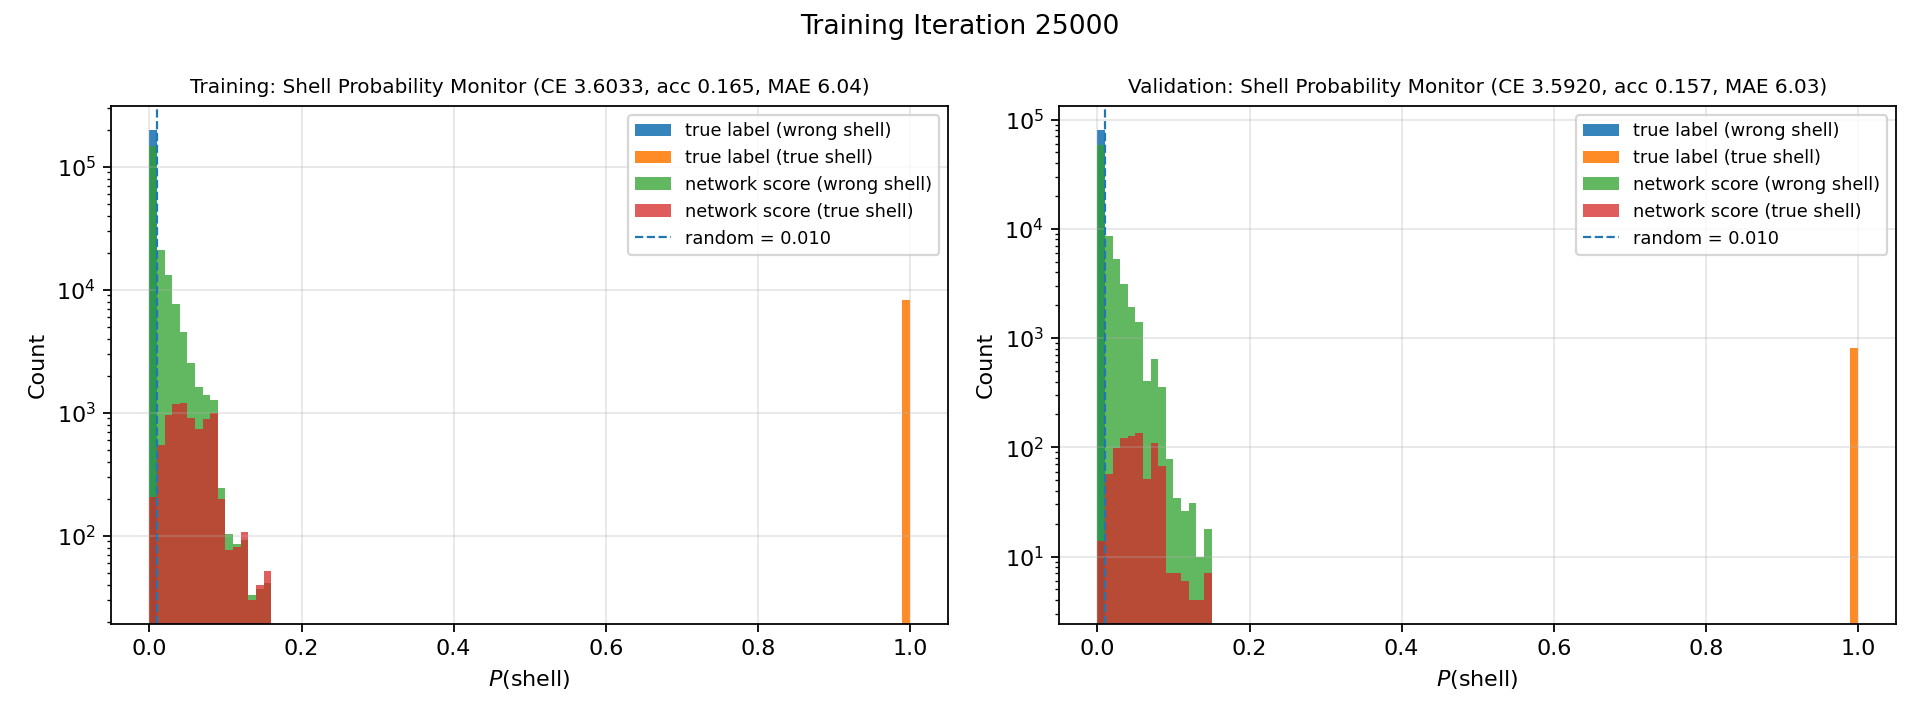

Epoch 7/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

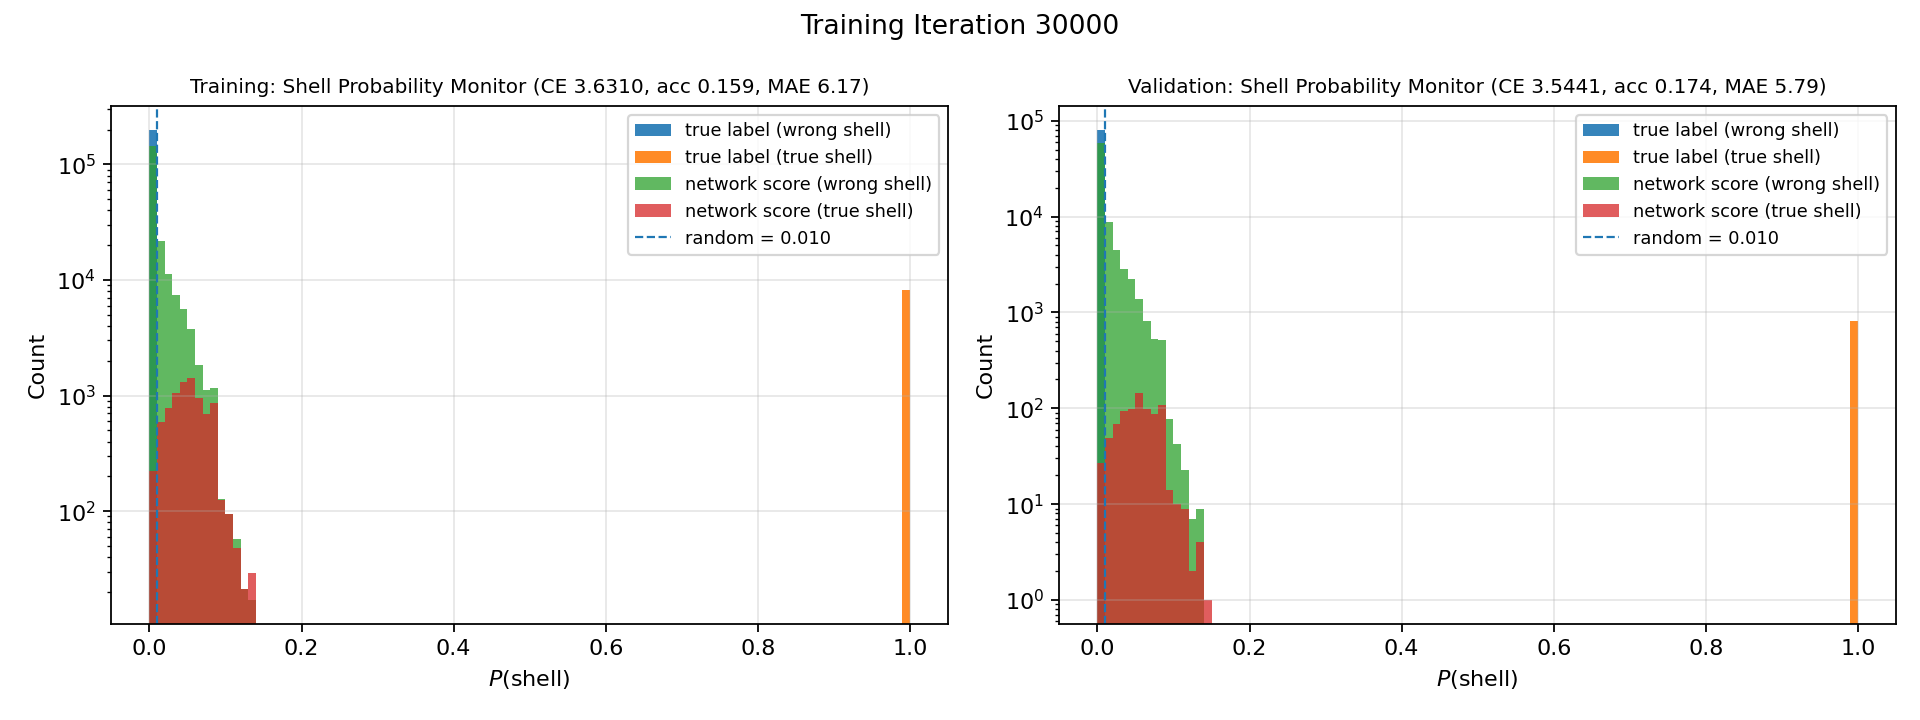

Epoch 8/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

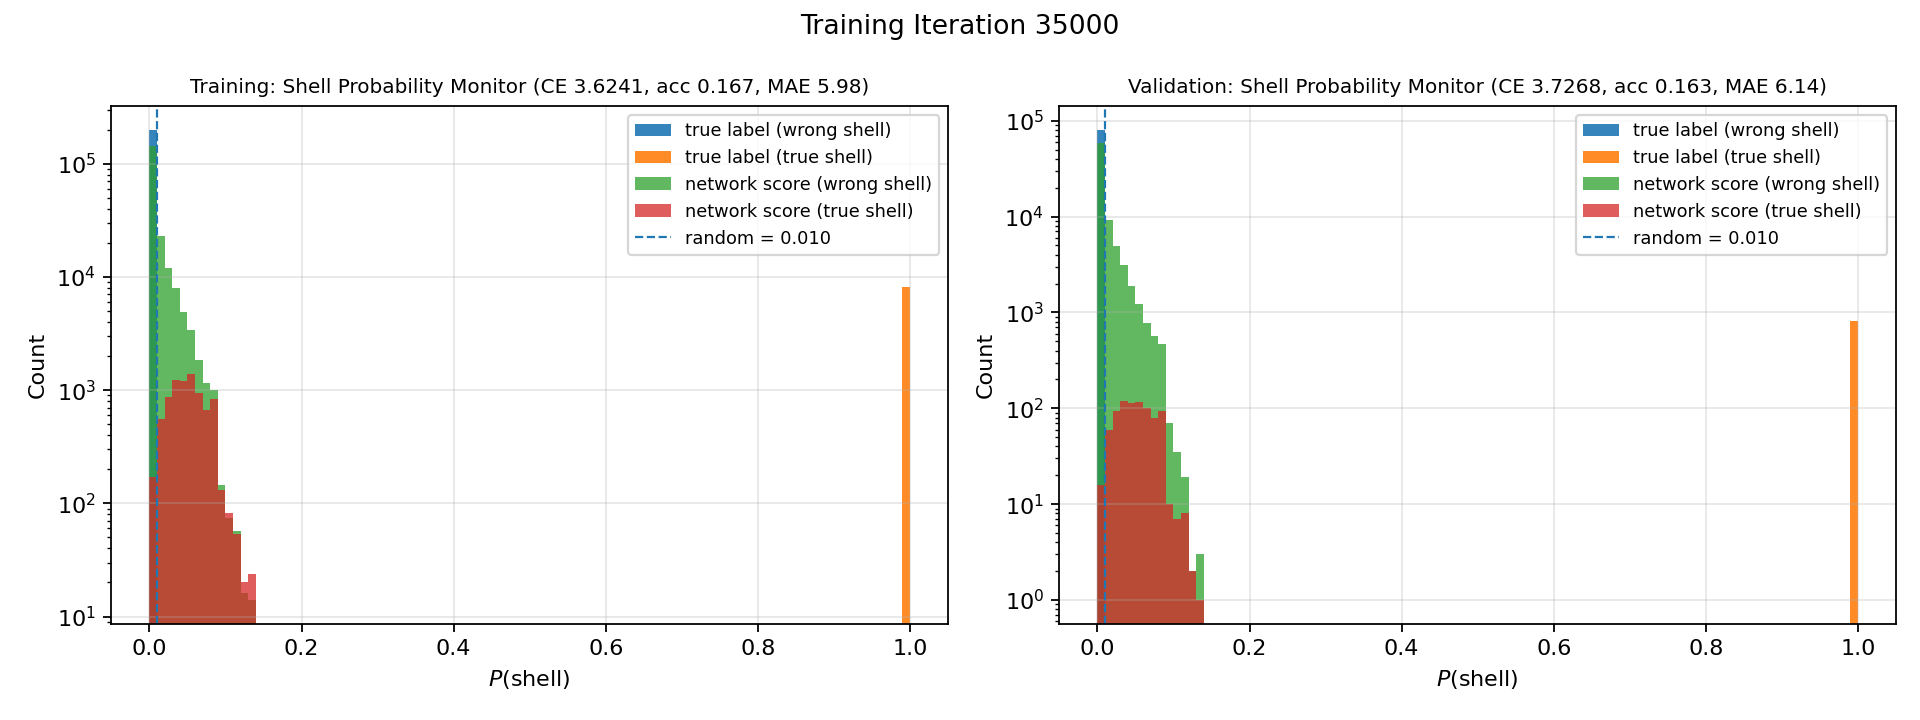

Epoch 9/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

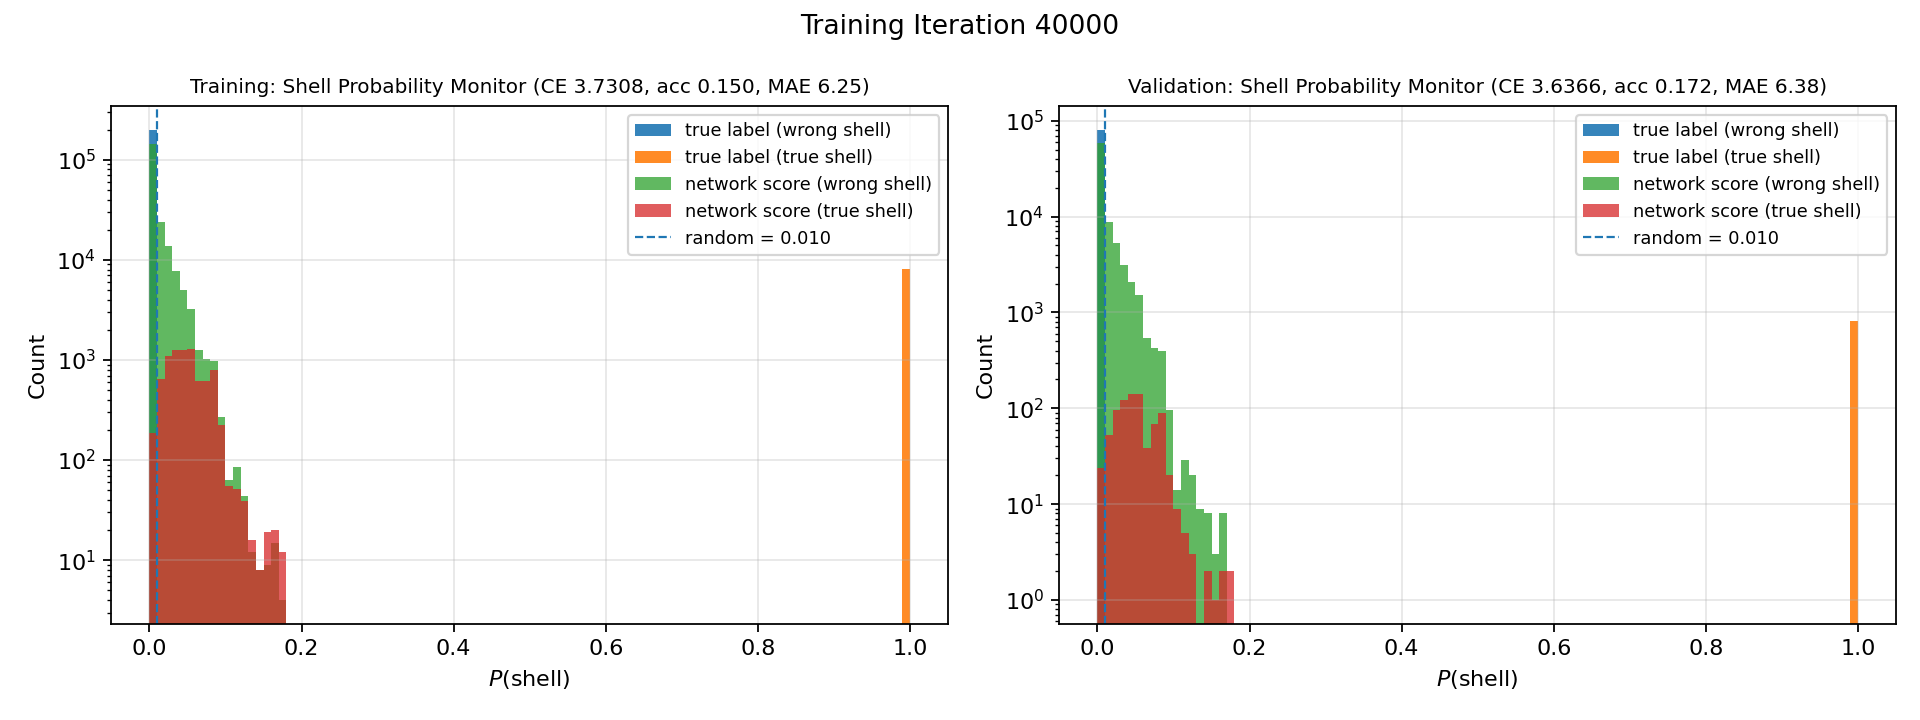

Epoch 10/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

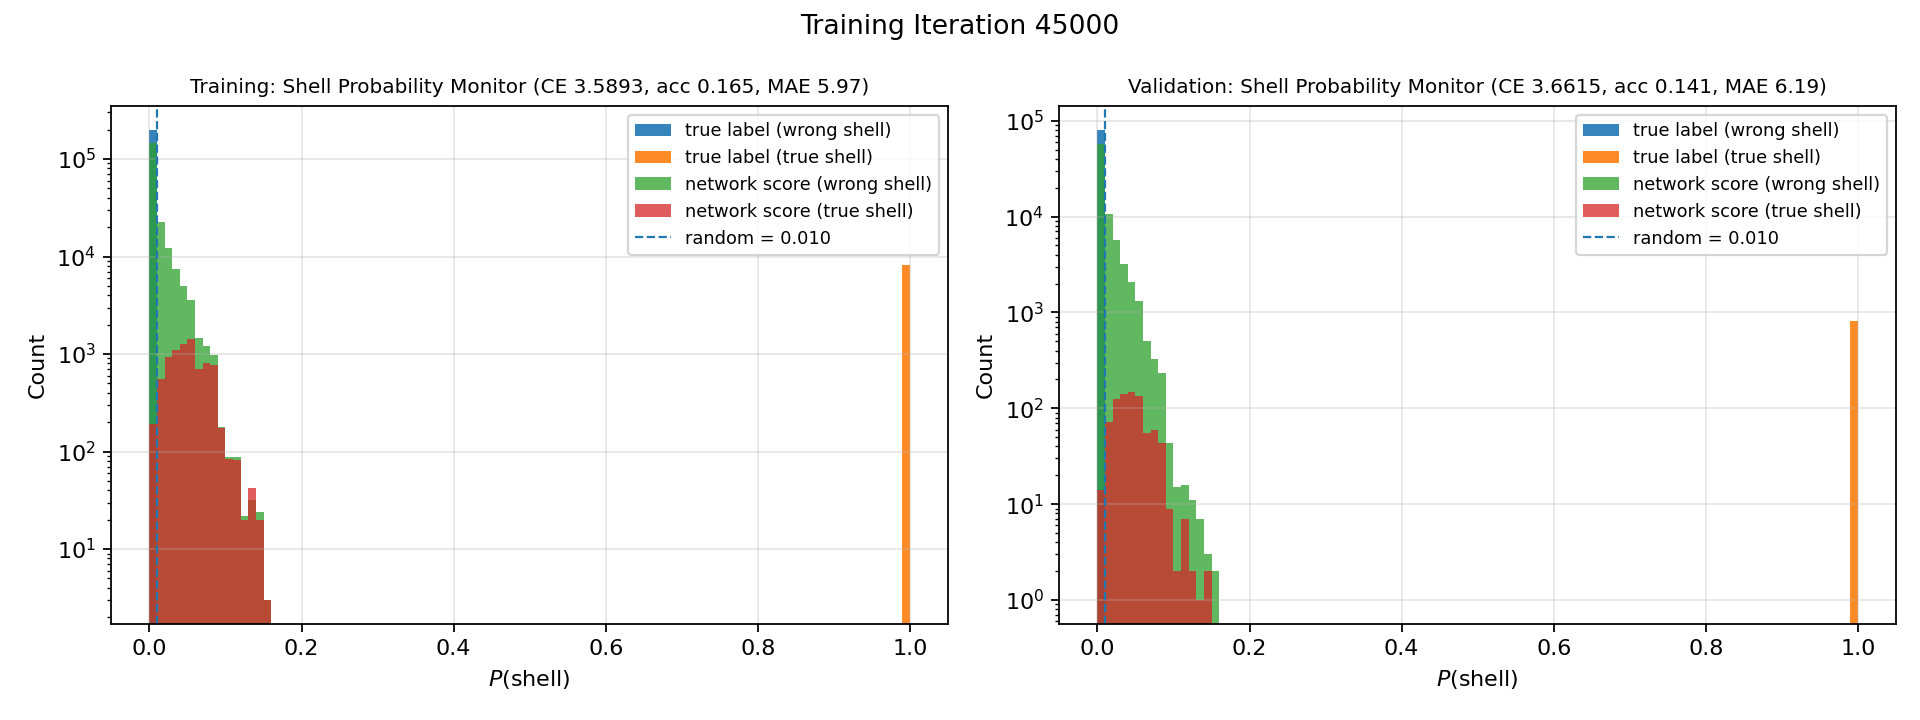

Epoch 11/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

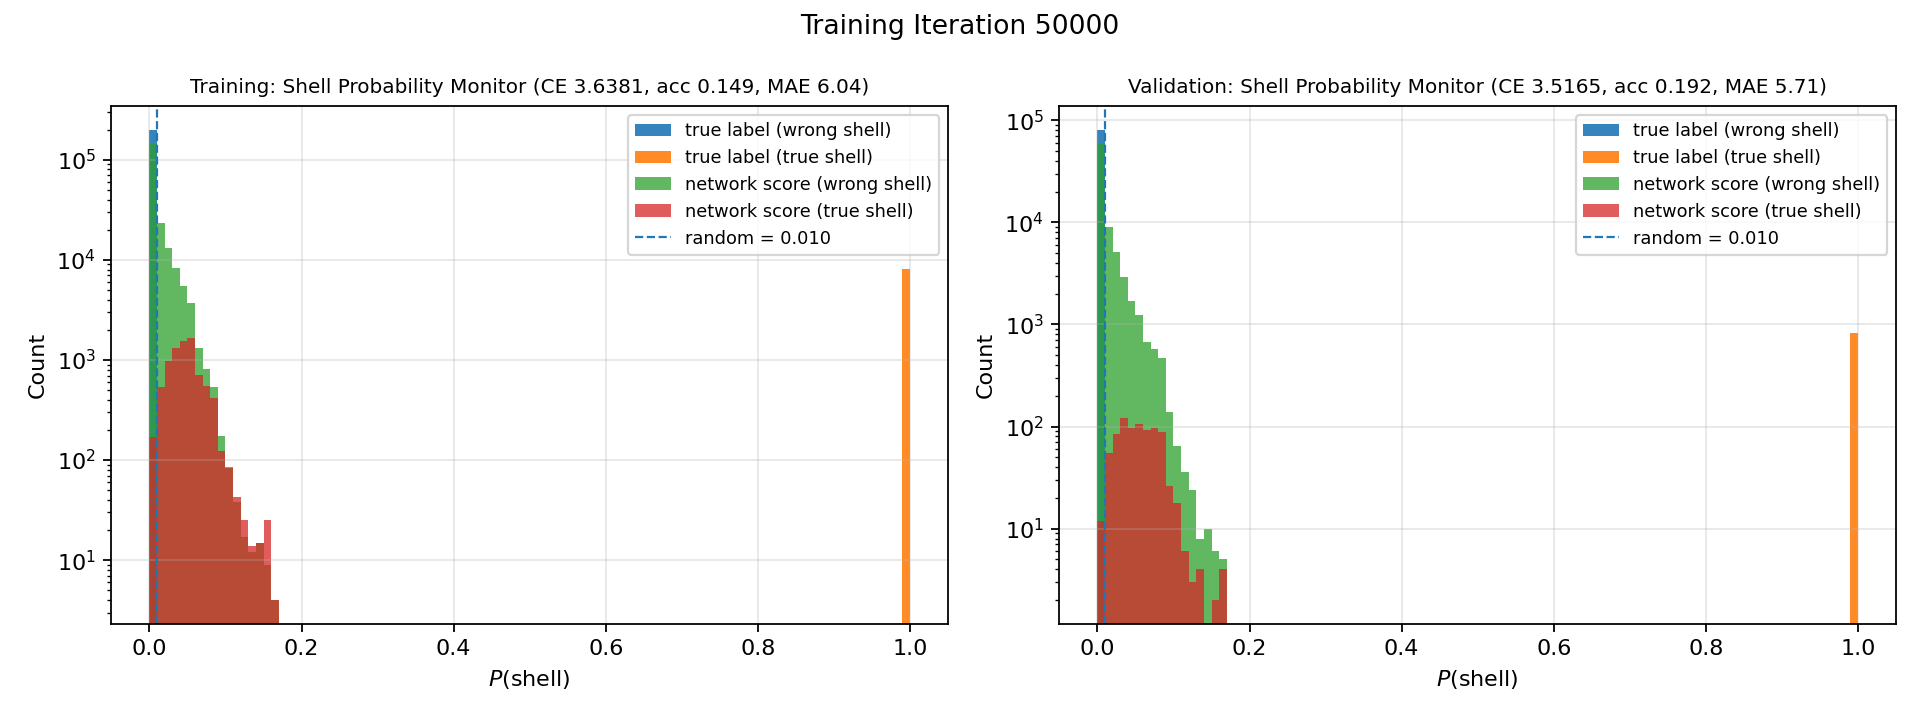

Epoch 12/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

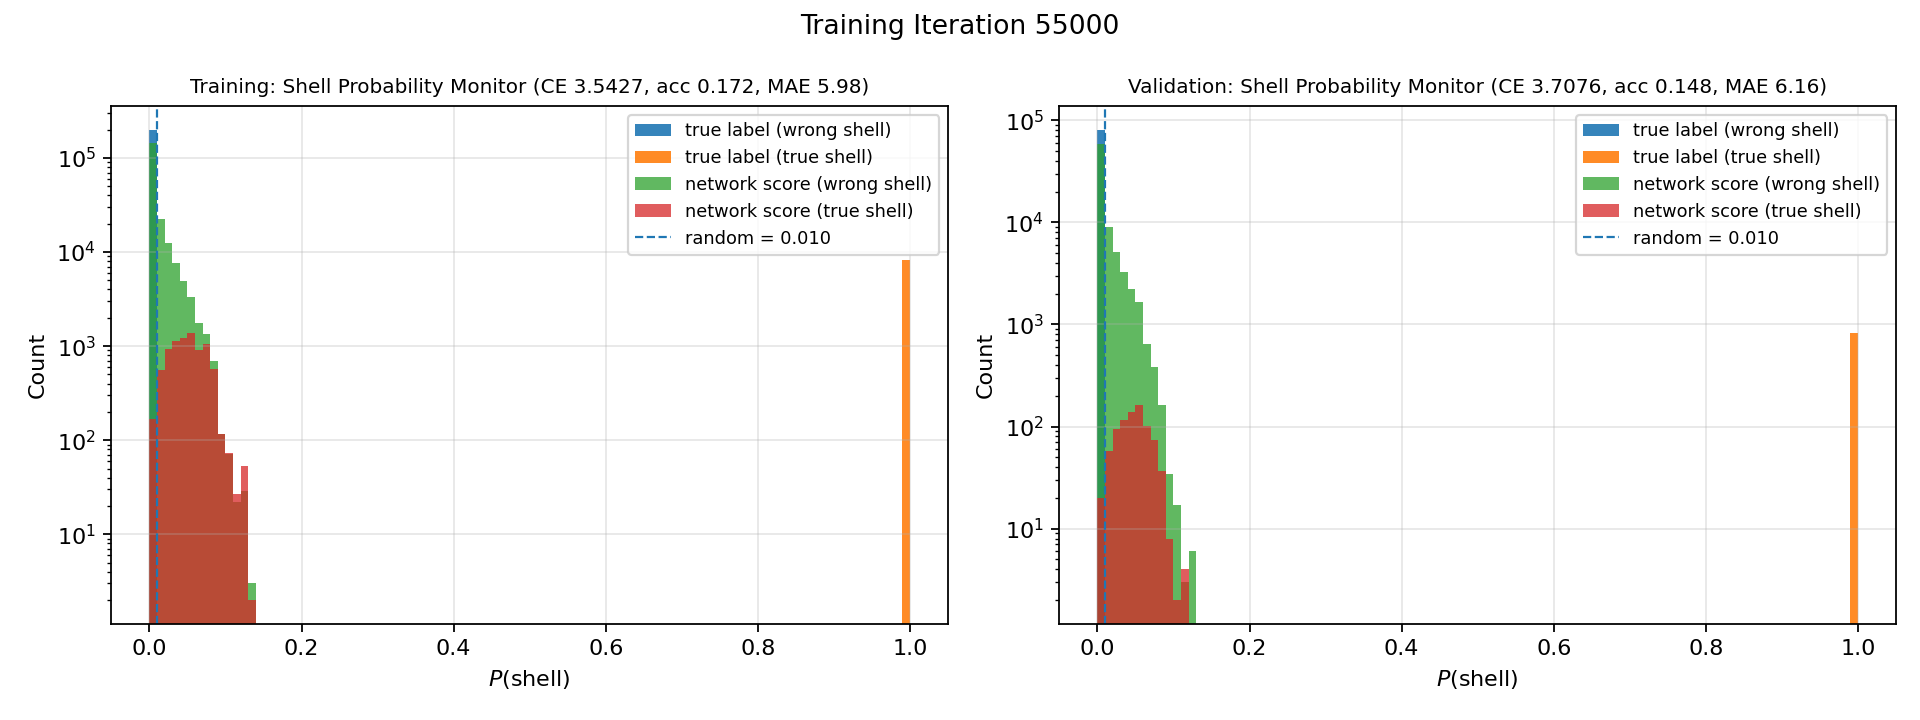

Epoch 13/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

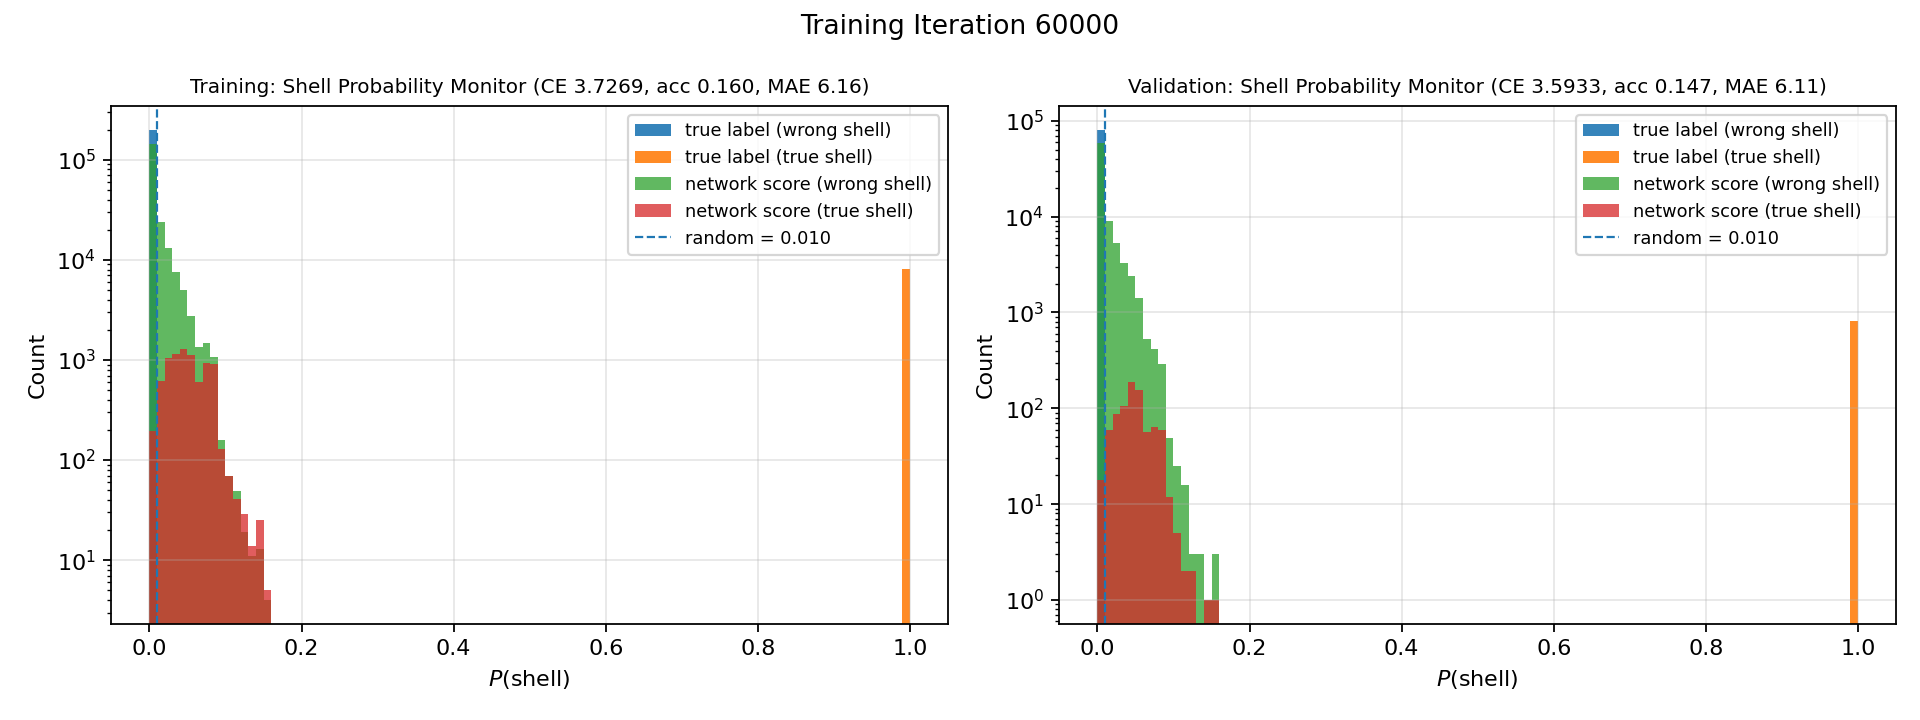

Epoch 14/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

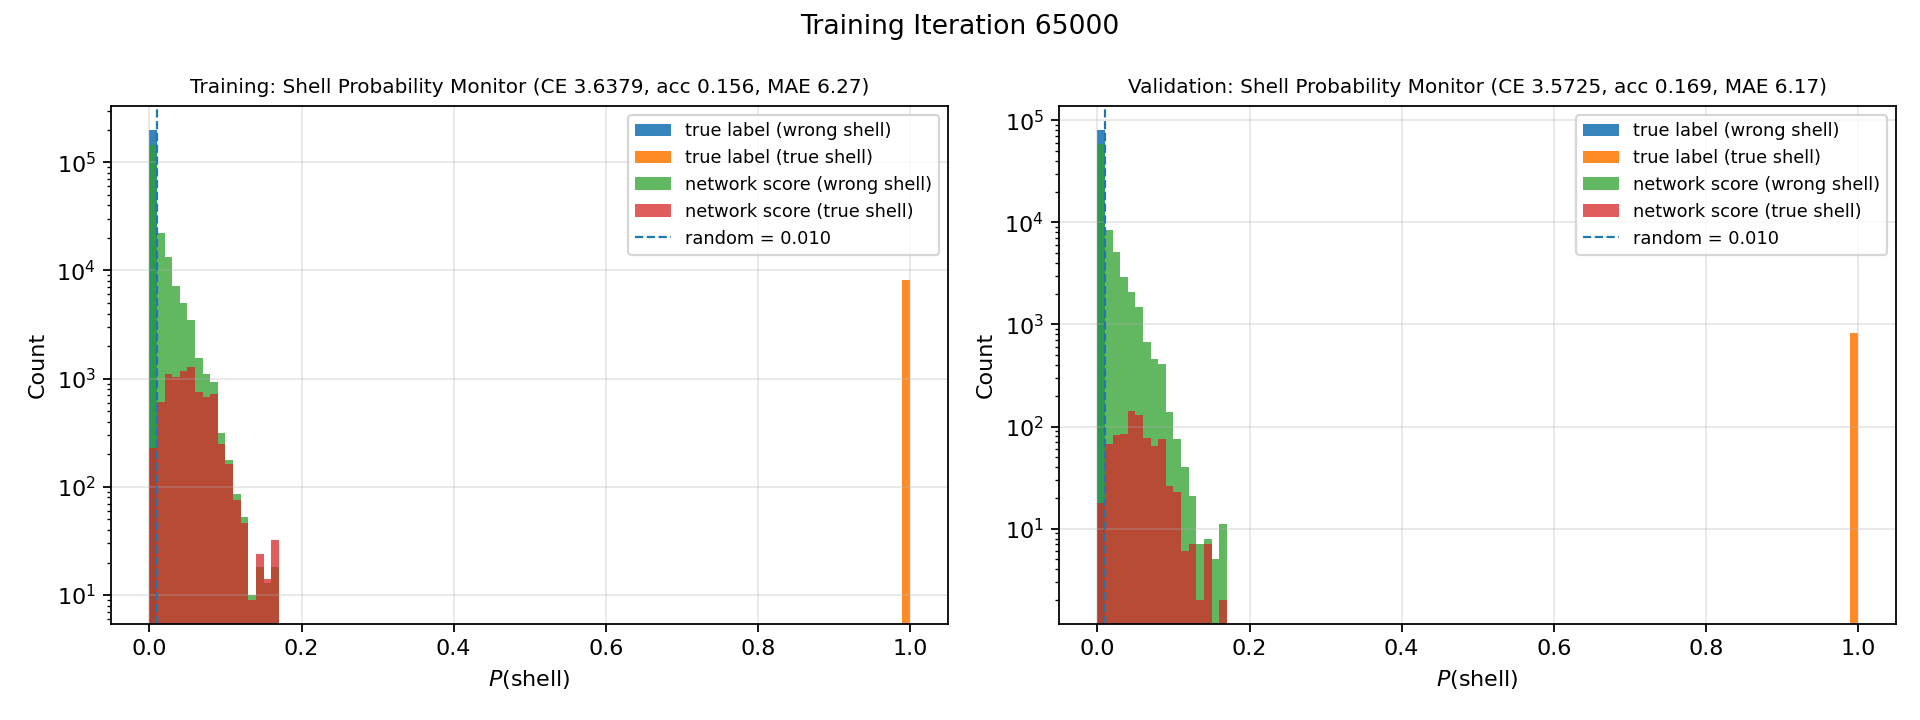

Epoch 15/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

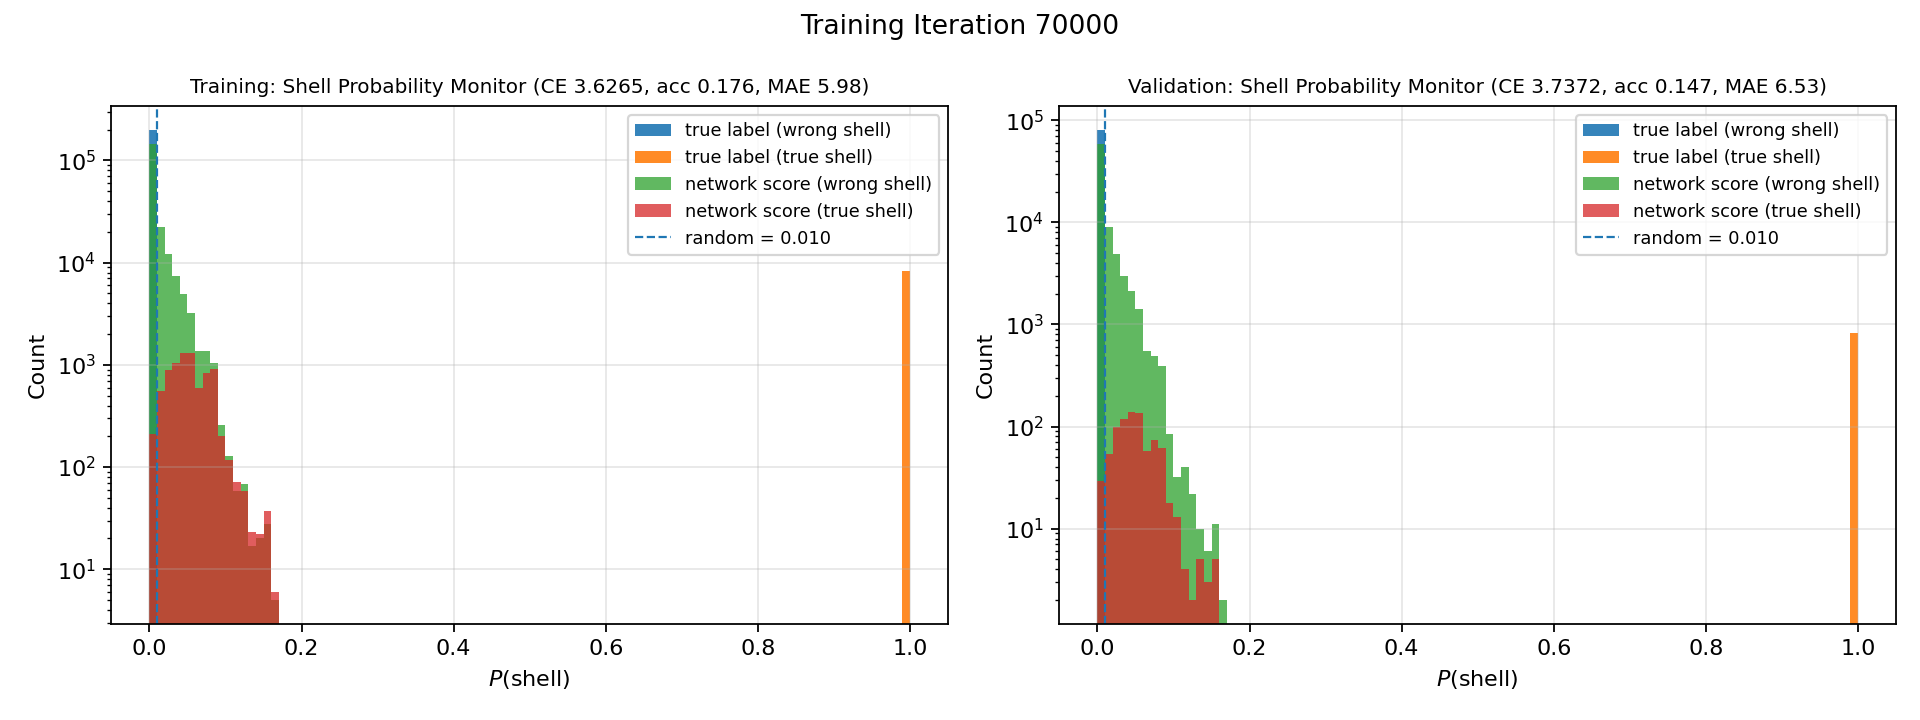

,artifact,path
0,model_path,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...
1,history_csv,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...
2,history_plot,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...
3,sample_plot,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...


In [5]:
train_result = train_cnp(
    runtime,
    steps_per_epoch=STEPS_PER_EPOCH,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    repr_dim=REPR_DIM,
    hidden=HIDDEN,
    dropout=DROPOUT,
    monitor_every=MONITOR_EVERY,
    show_monitor_plots=True,
)

pd.DataFrame({
    "artifact": ["model_path", "history_csv", "history_plot", "sample_plot"],
    "path": [
        str(train_result.model_path),
        str(train_result.history_csv),
        str(train_result.history_plot),
        str(train_result.sample_plot),
    ],
})


## 5. Predict On Training LF/HF And Validation HF


In [6]:
train_prediction = predict_cnp(
    runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
    output_suffix="train",
    all_shells=False,
)

validation_prediction = predict_cnp(
    validation_runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
    output_suffix="validation",
    all_shells=False,
)

pd.DataFrame({
    "artifact": [
        "train_all",
        "train_best",
        "train_mfgp",
        "validation_all",
        "validation_best",
        "validation_mfgp",
    ],
    "path": [
        str(train_prediction.all_path),
        str(train_prediction.best_path),
        str(train_prediction.mfgp_path),
        str(validation_prediction.all_path),
        str(validation_prediction.best_path),
        str(validation_prediction.mfgp_path),
    ],
})



Starting CNP prediction
Save all-shell CSV: False


TRAINING:   0%|          | 0/164 [00:00<?, ?block/s]

TRAINING:   0%|          | 0/12 [00:00<?, ?block/s]


MFGP CSV:       /home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp/cnp_xlzd_shell_minibatch_train_15epochs.csv
All-shell CSV:  not saved (all_shells=False)
Best-shell CSV: /home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp/cnp_xlzd_shell_minibatch_train_15epochs_best_shell.csv

Starting CNP prediction
Save all-shell CSV: False


VALIDATION:   0%|          | 0/8 [00:00<?, ?block/s]


MFGP CSV:       /home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs.csv
All-shell CSV:  not saved (all_shells=False)
Best-shell CSV: /home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs_best_shell.csv


,artifact,path
0,train_all,None
1,train_best,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...
2,train_mfgp,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...
3,validation_all,None
4,validation_best,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...
5,validation_mfgp,/home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp...


## 6. Inspect CNP Outputs


(<Figure size 1200x800 with 2 Axes>,
 [<Axes: title={'center': 'Predicted Shell Distribution'}, xlabel='Shell Number', ylabel='Count'>,
  <Axes: title={'center': 'True Shell Distribution'}, xlabel='Shell Number', ylabel='Count'>])

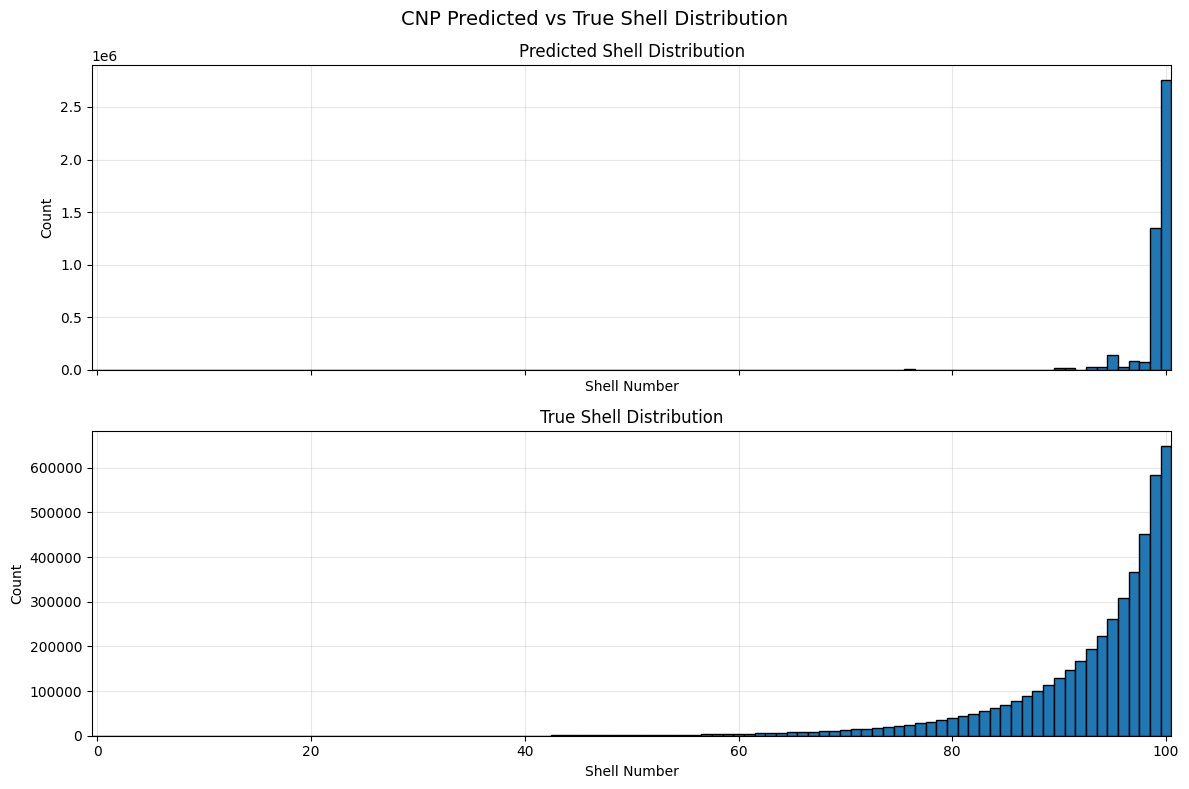

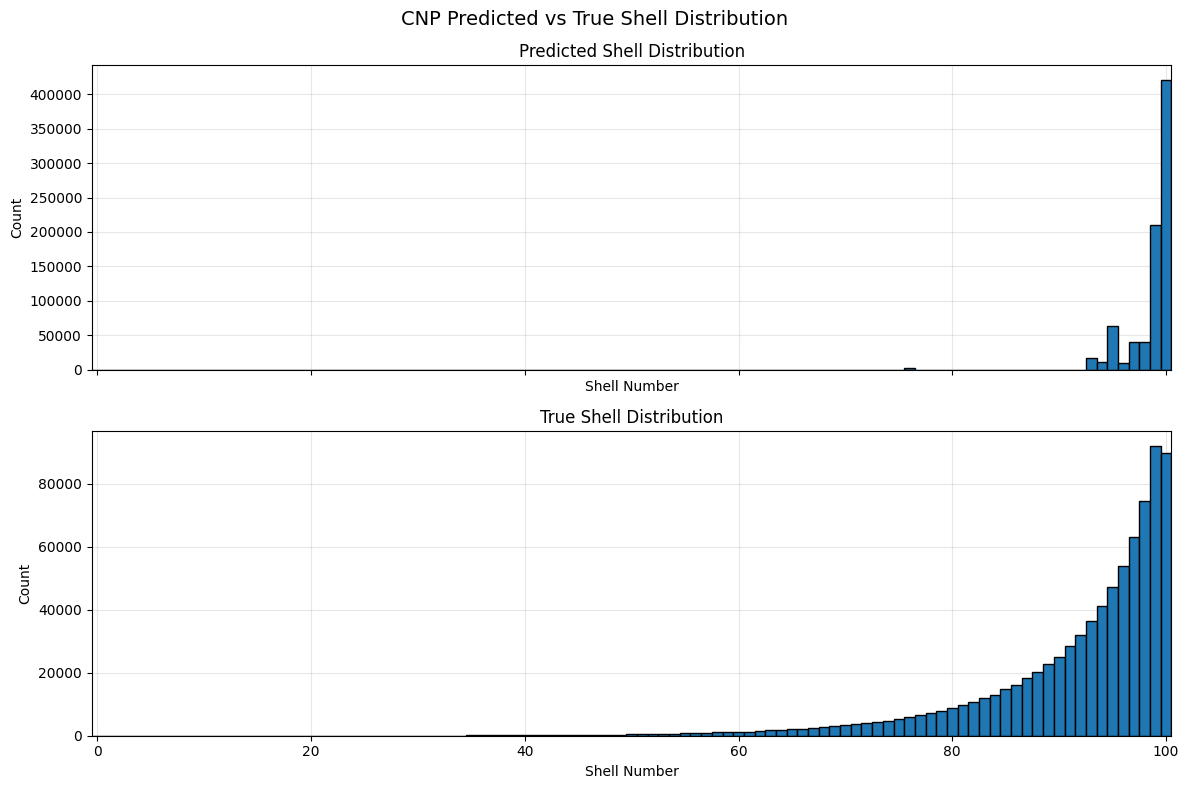

In [7]:
from cnp_mfgp.visualize import plot_cnp_pred_shell_occupancy

plot_cnp_pred_shell_occupancy(train_prediction)
plot_cnp_pred_shell_occupancy(validation_prediction)

## 7. Fit The MF-GP Transform Suite


In [8]:
cnp_train_csv = train_prediction.mfgp_path
cnp_val_csv = validation_prediction.mfgp_path

mfgp_results = run_mfgp_transform_suite(
    config_path=CONFIG_PATH,
    cnp_csv=cnp_train_csv,
    validation_csv=cnp_val_csv,
    transforms=TARGET_TRANSFORMS,
    iteration=0,
    grid_points_per_axis=GRID_POINTS,
    random_state=RANDOM_STATE,
    predict_chunk_size=CHUNK_SIZE,
    verbose=True,
)

metrics_rows = []
for transform, result in mfgp_results.items():
    metrics_path = getattr(result, "metrics_json", None)
    if metrics_path and Path(metrics_path).exists():
        payload = json.loads(Path(metrics_path).read_text())
        metrics_rows.append({"transform": transform, **payload})
pd.DataFrame(metrics_rows) if metrics_rows else pd.DataFrame()



=== Running MF-GP target transform: linear ===
[stage] Loading runtime config...
[stage] Using CNP CSV: /home/liuser/pknauss/XLZD/cnp_mfgp/outputs/cnp/cnp_xlzd_shell_minibatch_train_15epochs.csv
[stage] Loading manifest-defined fidelity rows using inputs ['detector_R', 'detector_Z']...
[data] LF fidelity=0, HF fidelity=1, n_lf=1, n_hf=1, x_dim=2


ValueError: Need at least 3 LF and 3 HF points

## 8. Display MF-GP Plots


In [ ]:
EXPERIMENT_TITLES = {
    "linear": "Normal MF-GP",
    "log_hf": "Log HF: emulate log10(y_raw)",
    "log_lf": "Log LF: use log10(y_cnp)",
    "log_both": "Log HF + Log LF: use log10(y_raw) and log10(y_cnp)",
}

PLOT_SELECTIONS = {
    "linear": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_hf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
    "log_lf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_both": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
}

def show_plot(result, label, key):
    value = getattr(result, key, None)
    if not value:
        return
    print(f"{label}: {value}")
    path = Path(value)
    if path.suffix.lower() == ".png" and path.exists():
        try:
            display(Image(filename=str(path)))
        except Exception:
            pass

for transform in TARGET_TRANSFORMS:
    result = mfgp_results.get(transform)
    if result is None:
        continue
    print(f"=== {EXPERIMENT_TITLES[transform]} ===")
    for label, key in PLOT_SELECTIONS[transform]:
        show_plot(result, label, key)
